# Estudo do uso de llms vs ML clássico

Aqui tentamos responder a pergunta: **Realmente há ganho no uso de LLMs para a triagem de artigos quando comparado com as abordagem clássicas de aprendizado de máquina?**

In [1]:
import pandas as pd
import numpy as np
from sklearn.metrics import accuracy_score
import os
from dotenv import load_dotenv, find_dotenv
from tqdm import tqdm
import matplotlib.pyplot as plt

In [2]:
import random

random.seed(42)
np.random.seed(42)

In [3]:
### style de execução
tqdm.pandas()

In [4]:
# 1. Configurar para exibir todas as linhas
pd.set_option('display.max_rows', None)

# 2. Configurar para exibir todas as colunas
pd.set_option('display.max_columns', None)

### variaveis de ambiente e conexões

In [5]:
# Carrega as variáveis do arquivo .env
load_dotenv("/data/codigos/.env")

True

In [6]:
for key in os.environ.keys():
    print(f'{key}')

HOSTNAME
HOME
GPG_KEY
PYTHON_SHA256
PATH
LANG
SHELL
PYTHON_VERSION
PWD
VSCODE_CWD
VSCODE_NLS_CONFIG
VSCODE_HANDLES_SIGPIPE
VSCODE_ESM_ENTRYPOINT
VSCODE_HANDLES_UNCAUGHT_ERRORS
REMOTE_CONTAINERS_IPC
REMOTE_CONTAINERS_SOCKETS
SHLVL
_
REMOTE_CONTAINERS
BROWSER
ELECTRON_RUN_AS_NODE
VSCODE_IPC_HOOK_CLI
APPLICATION_INSIGHTS_NO_STATSBEAT
VSCODE_L10N_BUNDLE_LOCATION
PYDEVD_IPYTHON_COMPATIBLE_DEBUGGING
PYTHONUNBUFFERED
PYTHONIOENCODING
PYTHON_FROZEN_MODULES
PYDEVD_USE_FRAME_EVAL
TERM
CLICOLOR
FORCE_COLOR
CLICOLOR_FORCE
PAGER
GIT_PAGER
MPLBACKEND
KMP_DUPLICATE_LIB_OK
KMP_INIT_AT_FORK
OPENAI_API_KEY_GOV_ANALITICA
GOOGLE_API_KEY_LLMS_PROF_DANILO
ANTROPIC_API_KEY_LLMS
TOGETHER_API_KEY_LLMS
GOOGLE_CLOUD_PROJECT
GOOGLE_CLOUD_REGION


## Leitura e processamento do arquivo

In [7]:
df_slr1 = pd.read_excel("/data/codigos/dados/titulo_resumo_palavras_slr1_v2.xlsx",engine='openpyxl')
df_slr1.head()

,ID,Title,resumo,keywords,sucesso_fracasso_resumo,sucesso_fracasso_palavras,segunda_coleta,obs
0,slr1_1,User Experience Design Using Machine Learning:...,ser experience (UX) is the key to increased pr...,"User experience, experience design, UX, ED, ma...",sucesso,sucesso,não,não estruturado
1,slr1_2,Sentiment analysis on arabic tweets: Challeng...,Sentiment analysis and opinion mining are desi...,"Twitter, Sentiment analysis, Opinion mining, N...",sucesso,sucesso,não,não estruturado
2,slr1_3,Machine learning\n based cognitive skills cal...,Advance measurement of cognitive skills of a h...,"Cognitive skills, Computational Intelligence,H...",sucesso,sucesso,não,não estruturado
3,slr1_4,Human Factors_x000D_\n Engineering in Interac...,This paper presents a systematic review of tec...,"Urban planning,Virtual reality,Mixed reality,A...",sucesso,sucesso,não,não estruturado
4,slr1_5,Empirical comparisons_x000D_\n for combining ...,The process of modelling individual player per...,"Class imbalance, data mining, data sampling, f...",sucesso,sucesso,não,não estruturado


In [8]:
df_slr1 = df_slr1.replace({r'_x000D_|\n': ''}, regex=True)

In [9]:
df_slr1.head()

,ID,Title,resumo,keywords,sucesso_fracasso_resumo,sucesso_fracasso_palavras,segunda_coleta,obs
0,slr1_1,User Experience Design Using Machine Learning:...,ser experience (UX) is the key to increased pr...,"User experience, experience design, UX, ED, ma...",sucesso,sucesso,não,não estruturado
1,slr1_2,Sentiment analysis on arabic tweets: Challeng...,Sentiment analysis and opinion mining are desi...,"Twitter, Sentiment analysis, Opinion mining, N...",sucesso,sucesso,não,não estruturado
2,slr1_3,Machine learning based cognitive skills calcu...,Advance measurement of cognitive skills of a h...,"Cognitive skills, Computational Intelligence,H...",sucesso,sucesso,não,não estruturado
3,slr1_4,Human Factors Engineering in Interactive Urba...,This paper presents a systematic review of tec...,"Urban planning,Virtual reality,Mixed reality,A...",sucesso,sucesso,não,não estruturado
4,slr1_5,Empirical comparisons for combining balancing...,The process of modelling individual player per...,"Class imbalance, data mining, data sampling, f...",sucesso,sucesso,não,não estruturado


#### Limpeza dos casos em que não conseguimos extrair as informações


In [10]:
# Calcula a quantidade de valores por nível no campo "sucesso_fracasso"
sucesso_fracasso_counts = df_slr1['sucesso_fracasso_resumo'].value_counts()
print(sucesso_fracasso_counts)

sucesso_fracasso_resumo
sucesso     132
fracasso      2
Name: count, dtype: int64


In [11]:
# Calcula a quantidade de valores por nível no campo "sucesso_fracasso"
sucesso_fracasso_counts2 = df_slr1['sucesso_fracasso_palavras'].value_counts()
print(sucesso_fracasso_counts2)

sucesso_fracasso_palavras
sucesso     126
fracasso      8
Name: count, dtype: int64


In [12]:
# aqui precisamos, para reproduzir o artigo que ambos os campos tenho informação
df_slr1_clear = df_slr1.loc[((df_slr1['sucesso_fracasso_resumo'].isin(['sucesso']))&(df_slr1['sucesso_fracasso_palavras'].isin(['sucesso'])))].copy()
df_slr1_clear.shape

(126, 8)

In [13]:
print(df_slr1_clear["sucesso_fracasso_resumo"].value_counts())
print(df_slr1_clear["sucesso_fracasso_palavras"].value_counts())

sucesso_fracasso_resumo
sucesso    126
Name: count, dtype: int64
sucesso_fracasso_palavras
sucesso    126
Name: count, dtype: int64


In [14]:
print("Shape antes da limpeza: "+str(df_slr1.shape))
print("Shape depois da limpeza"+str(df_slr1_clear.shape))

Shape antes da limpeza: (134, 8)
Shape depois da limpeza(126, 8)


In [15]:
# Renomear as colunas do dataframe df_slr1_clear
df_slr1_clear.rename(columns={"Title": "title", "resumo": "abstract"}, inplace=True)
df_slr1_clear.head(2)

,ID,title,abstract,keywords,sucesso_fracasso_resumo,sucesso_fracasso_palavras,segunda_coleta,obs
0,slr1_1,User Experience Design Using Machine Learning:...,ser experience (UX) is the key to increased pr...,"User experience, experience design, UX, ED, ma...",sucesso,sucesso,não,não estruturado
1,slr1_2,Sentiment analysis on arabic tweets: Challeng...,Sentiment analysis and opinion mining are desi...,"Twitter, Sentiment analysis, Opinion mining, N...",sucesso,sucesso,não,não estruturado


### ETL

In [16]:
import re
from sklearn.feature_extraction import text as sk_text

In [17]:
df_slr1_etl = df_slr1_clear.copy()

In [18]:
# se houver NaN, substitui por string vazia
for col in ["title", "abstract", "keywords"]:
    if col not in df_slr1_etl.columns:
        raise ValueError(f"Coluna ausente: {col}")
    df_slr1_etl[col] = df_slr1_etl[col].fillna("").astype(str)

In [19]:
# --- stopwords (inglês, sklearn)
EN_STOPWORDS = set(sk_text.ENGLISH_STOP_WORDS)

In [20]:
# --- limpeza básica: minúsculas, remover pontuação e múltiplos espaços
# obs: mantemos letras, dígitos e hífens (para termos compostos), trocando o resto por espaço
def _clean_series(s: pd.Series) -> pd.Series:
    s = s.str.lower()
    s = s.str.replace(r"[^a-z0-9\-]+", " ", regex=True)   # remove pontuação/sinais
    s = s.str.replace(r"\s+", " ", regex=True).str.strip() # normaliza espaços
    return s


In [21]:
df_slr1_etl["title"]    = _clean_series(df_slr1_etl["title"])
df_slr1_etl["abstract"] = _clean_series(df_slr1_etl["abstract"])
df_slr1_etl["keywords"] = (
    df_slr1_etl["keywords"].str.replace(r"[;,|]", " ", regex=True)  # separadores comuns
                       .pipe(_clean_series)
)

In [22]:
df_slr1_etl.head(2)

,ID,title,abstract,keywords,sucesso_fracasso_resumo,sucesso_fracasso_palavras,segunda_coleta,obs
0,slr1_1,user experience design using machine learning ...,ser experience ux is the key to increased prod...,user experience experience design ux ed machin...,sucesso,sucesso,não,não estruturado
1,slr1_2,sentiment analysis on arabic tweets challenges...,sentiment analysis and opinion mining are desi...,twitter sentiment analysis opinion mining natu...,sucesso,sucesso,não,não estruturado


In [23]:
print(df_slr1_etl["abstract"].iloc[0])

ser experience ux is the key to increased productivity by enhancing the usability and interactivity of the product machine learning ml solutions have raised user and academic awareness of technical innovation as a result ml is becoming increasingly popular to improve the quality of ux several investigations have highlighted a potential lack of studies on the overall challenges and recommendations for ux using ml therefore more attention should be paid to ml s existence and potential applications across various applications to get the most out of ml techniques to improve the ux design process to this objective a systematic review of the literature was performed as to determine the challenges faced by ux designers when incorporating ml in their design process recommendations that help ux designers incorporate ml into ux design will be highlighted furthermore the prisma approach is used a process that has been established in the literature to restrict the chance of bias at the selection s

In [24]:
# --- remoção de stopwords e tokens muito curtos (ex.: 1 char)
def _rm_stop_and_short(s: pd.Series, stopwords=EN_STOPWORDS, min_len=2) -> pd.Series:
    # divide por espaço, remove stopwords e tokens curtos, reagrupa
    def _proc(text: str) -> str:
        toks = text.split()
        toks = [t for t in toks if (t not in stopwords) and (len(t) >= min_len)]
        return " ".join(toks)
    return s.apply(_proc)

In [25]:
df_slr1_etl["title"]    = _rm_stop_and_short(df_slr1_etl["title"])
df_slr1_etl["abstract"] = _rm_stop_and_short(df_slr1_etl["abstract"])
df_slr1_etl["keywords"] = _rm_stop_and_short(df_slr1_etl["keywords"])


In [26]:
print(df_slr1_etl["abstract"].iloc[0])

ser experience ux key increased productivity enhancing usability interactivity product machine learning ml solutions raised user academic awareness technical innovation result ml increasingly popular improve quality ux investigations highlighted potential lack studies overall challenges recommendations ux using ml attention paid ml existence potential applications various applications ml techniques improve ux design process objective systematic review literature performed determine challenges faced ux designers incorporating ml design process recommendations help ux designers incorporate ml ux design highlighted furthermore prisma approach used process established literature restrict chance bias selection stage relevant articles following databases searched ieee xplore scopus web science acm findings revealed number publications issues linked ux ml advanced exponentially review highlights challenges recommendations tools algorithms techniques datasets used different studies addition su

In [27]:
# combinando o titulo, resumo e palavras-chave em um único campo
df_slr1_etl["title_abstract_keywords"]   = (df_slr1_etl["title"] + " " + df_slr1_etl["abstract"] + " " + df_slr1_etl["keywords"]).str.strip()

In [28]:
df_slr1_etl.head(1)

,ID,title,abstract,keywords,sucesso_fracasso_resumo,sucesso_fracasso_palavras,segunda_coleta,obs,title_abstract_keywords
0,slr1_1,user experience design using machine learning ...,ser experience ux key increased productivity e...,user experience experience design ux ed machin...,sucesso,sucesso,não,não estruturado,user experience design using machine learning ...


In [29]:
print(df_slr1_etl["title_abstract_keywords"].iloc[0])

user experience design using machine learning systematic review ser experience ux key increased productivity enhancing usability interactivity product machine learning ml solutions raised user academic awareness technical innovation result ml increasingly popular improve quality ux investigations highlighted potential lack studies overall challenges recommendations ux using ml attention paid ml existence potential applications various applications ml techniques improve ux design process objective systematic review literature performed determine challenges faced ux designers incorporating ml design process recommendations help ux designers incorporate ml ux design highlighted furthermore prisma approach used process established literature restrict chance bias selection stage relevant articles following databases searched ieee xplore scopus web science acm findings revealed number publications issues linked ux ml advanced exponentially review highlights challenges recommendations tools a

### Trazendo o rotulo

In [30]:
# vamos trazer os dados disponibilizados pelos autores para comparação de performance
df_slr1_autores = pd.read_excel("/data/codigos/dados/SLR1-results-keys.xlsx",engine='openpyxl')
df_slr1_autores.head()

,ID,Title,IC1,IC2,Benchmark,Execution time (s),Total Tokens
0,slr1_1,User Experience_x000D_\n Design Using Machine...,7.0,6.0,I,1.321527,955.0
1,slr1_2,Sentiment analysis_x000D_\n on arabic tweets:...,7.0,4.0,E,0.922849,707.0
2,slr1_3,Machine learning_x000D_\n based cognitive ski...,7.0,6.0,E,1.285468,705.0
3,slr1_4,Human Factors_x000D_\n Engineering in Interac...,7.0,4.0,E,1.144713,783.0
4,slr1_5,Empirical comparisons_x000D_\n for combining ...,1.0,4.0,E,1.152106,1327.0


In [31]:
print("Shape antes do merge: "+str(df_slr1_etl.shape))
df_slr1_etl = pd.merge(left=df_slr1_etl, right=df_slr1_autores[["ID","Benchmark"]],
                          left_on='ID', right_on='ID',how='left')
print("Shape depois do merge: "+str(df_slr1_etl.shape))

Shape antes do merge: (126, 9)
Shape depois do merge: (126, 10)


In [32]:
def convert_benchmark(df,col1):
    df["result_bench"] = np.where(df[col1].str.lower()=="i",1,0)
    return df

In [33]:

df_slr1_etl = convert_benchmark(df_slr1_etl,"Benchmark")

In [34]:
df_slr1_etl.head(2)

,ID,title,abstract,keywords,sucesso_fracasso_resumo,sucesso_fracasso_palavras,segunda_coleta,obs,title_abstract_keywords,Benchmark,result_bench
0,slr1_1,user experience design using machine learning ...,ser experience ux key increased productivity e...,user experience experience design ux ed machin...,sucesso,sucesso,não,não estruturado,user experience design using machine learning ...,I,1
1,slr1_2,sentiment analysis arabic tweets challenges di...,sentiment analysis opinion mining designed det...,twitter sentiment analysis opinion mining natu...,sucesso,sucesso,não,não estruturado,sentiment analysis arabic tweets challenges di...,E,0


##  modelagem

### TF-IDF e Split

In [35]:
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer

In [36]:
df_slr1_etl["result_bench"].value_counts(normalize=True)

result_bench
0    0.611111
1    0.388889
Name: proportion, dtype: float64

In [37]:
test_size = 50/len(df_slr1_etl)
print("Tamanho do dataset: "+str(len(df_slr1_etl)))
print("Tamanho do dataset de teste em proporção: "+str(test_size))

Tamanho do dataset: 126
Tamanho do dataset de teste em proporção: 0.3968253968253968


In [38]:
# so verificando o valor precisa ser 50
test_size*len(df_slr1_etl)

50.0

In [39]:

idx = np.arange(len(df_slr1_etl))  # índices de linha
y_df = df_slr1_etl["result_bench"].astype(int).values

idx_tr, idx_te, y_tr, y_te = train_test_split(
    idx, y_df,
    test_size=(1-test_size), random_state=42, stratify=y_df
)

# marque no DF para uso futuro
df_slr1_etl["split"] = "train"
df_slr1_etl.loc[idx_te, "split"] = "test"

In [40]:
# se quiser coleções com os IDs correspondentes (atenção: podem repetir)
ids_train = df_slr1_etl.loc[idx_tr, "ID"].tolist()
ids_test  = df_slr1_etl.loc[idx_te, "ID"].tolist()

In [41]:
len(ids_train), len(ids_test)

(49, 77)

In [42]:
# depois você pode filtrar:
df_train = df_slr1_etl[df_slr1_etl["split"]=="train"].copy()
df_test  = df_slr1_etl[df_slr1_etl["split"]=="test"].copy()

# e pegar os textos/labels
X_tr_text = df_train["title_abstract_keywords"]
X_te_text = df_test["title_abstract_keywords"]
y_tr = df_train["result_bench"].astype(int).values
y_te = df_test["result_bench"].astype(int).values


In [43]:
# 3) Vetorização TF-IDF (fit no treino, transform no teste)
tfidf = TfidfVectorizer(
    stop_words="english",   # ok manter, mesmo com limpeza prévia
    ngram_range=(1,2),      # unigrams+bigramas (ajuste se quiser)
    max_features=50000,
    min_df=2,
    sublinear_tf=True,
    lowercase=True,
    norm="l2"
)

X_tr = tfidf.fit_transform(X_tr_text)   # só treino
X_te  = tfidf.transform(X_te_text)      # aplica ao teste

print("Shapes TF-IDF:", X_tr.shape, X_te.shape)

Shapes TF-IDF: (49, 994) (77, 994)


In [44]:
X_tr

<49x994 sparse matrix of type '<class 'numpy.float64'>'
	with 4037 stored elements in Compressed Sparse Row format>

### Treino e avaliacao do modelo simples

In [45]:
import matplotlib.pyplot as plt
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score, f1_score, roc_auc_score,
    RocCurveDisplay, PrecisionRecallDisplay,
    average_precision_score, classification_report,
    confusion_matrix
)

In [46]:
clf = LogisticRegression(
    solver="liblinear",      # bom para dados esparsos
    penalty="l2",
    class_weight="balanced", # útil se classes desbalanceadas
    max_iter=1000,
    random_state=42,
    n_jobs=None              # remova se versão do sklearn não aceitar
)
clf.fit(X_tr, y_tr)

LogisticRegression(class_weight='balanced', max_iter=1000, random_state=42,
                   solver='liblinear')

In [47]:
y_proba = clf.predict_proba(X_te)[:, 1]  # probabilidade da classe positiva
y_pred  = (y_proba >= 0.5).astype(int)   # decisão com threshold 0.5 (ajustável)

In [48]:
acc  = accuracy_score(y_te, y_pred)
f1   = f1_score(y_te, y_pred)
auc  = roc_auc_score(y_te, y_proba)
ap   = average_precision_score(y_te, y_proba)  # área sob PR (AP)

print(f"Accuracy: {acc:.4f}")
print(f"F1-score: {f1:.4f}")
print(f"ROC-AUC : {auc:.4f}")
print(f"PR-AUC (AP): {ap:.4f}")
print("\nClassification report:\n", classification_report(y_te, y_pred, digits=3))



Accuracy: 0.7403
F1-score: 0.6970
ROC-AUC : 0.8064
PR-AUC (AP): 0.7211

Classification report:
               precision    recall  f1-score   support

           0      0.829     0.723     0.773        47
           1      0.639     0.767     0.697        30

    accuracy                          0.740        77
   macro avg      0.734     0.745     0.735        77
weighted avg      0.755     0.740     0.743        77



In [49]:
# (opcional) Matriz de confusão
cm = confusion_matrix(y_te, y_pred)
print("Confusion matrix:\n", cm)

Confusion matrix:
 [[34 13]
 [ 7 23]]


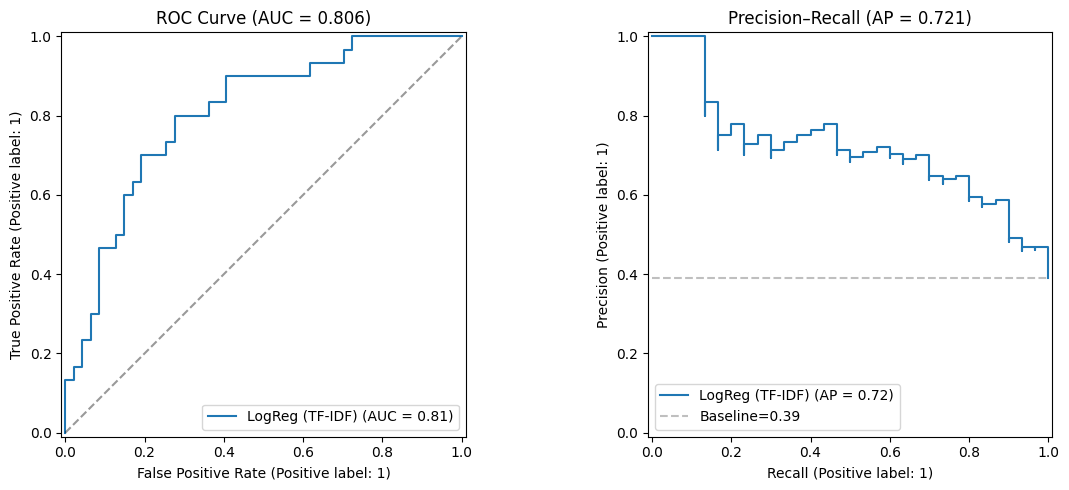

In [50]:
fig, ax = plt.subplots(1, 2, figsize=(12, 5))

RocCurveDisplay.from_predictions(
    y_te, y_proba,
    name="LogReg (TF-IDF)",
    ax=ax[0]
)
ax[0].plot([0,1], [0,1], 'k--', alpha=0.4)
ax[0].set_title(f"ROC Curve (AUC = {auc:.3f})")

# ----- 5) Curva Precision–Recall ---------------------------------------------
PrecisionRecallDisplay.from_predictions(
    y_te, y_proba,
    name="LogReg (TF-IDF)",
    ax=ax[1]
)
# linha de base = prevalência da classe positiva
pos_rate = np.mean(y_te)
ax[1].hlines(pos_rate, 0, 1, colors="gray", linestyles="--", alpha=0.5, label=f"Baseline={pos_rate:.2f}")
ax[1].legend(loc="lower left")
ax[1].set_title(f"Precision–Recall (AP = {ap:.3f})")

plt.tight_layout()
plt.show()

### Treino de vários modelos

In [51]:
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.naive_bayes import MultinomialNB

In [52]:
def get_scores(clf, X):
    """
    Retorna um vetor de 'scores' contínuos para métricas baseadas em ranking:
      - Se tiver predict_proba, usa proba[:,1]
      - Senão, usa decision_function
      - Como fallback (raro), usa a predição binária (pobre para AUC/AP)
    """
    if hasattr(clf, "predict_proba"):
        return clf.predict_proba(X)[:, 1]
    elif hasattr(clf, "decision_function"):
        s = clf.decision_function(X)
        # garantir 1D
        return s.ravel() if hasattr(s, "ravel") else s
    else:
        return clf.predict(X).astype(float)

# ----------------------------------
# util: bootstrap CI para Acc e F1
# ----------------------------------
def bootstrap_ci_acc_f1(y_true, y_pred, B=2000, seed=123):
    """
    Bootstrap simples no conjunto de teste para IC95% de Accuracy e F1.
    Aceita pandas Series ou arrays; converte para NumPy internamente.
    """
    # --- garante NumPy 1D ---
    y_true = np.asarray(y_true).ravel()
    y_pred = np.asarray(y_pred).ravel()

    assert y_true.shape == y_pred.shape, "y_true e y_pred com comprimentos diferentes."

    rng = np.random.default_rng(seed)
    n = y_true.shape[0]

    accs = np.empty(B, dtype=float)
    f1s  = np.empty(B, dtype=float)

    for b in range(B):
        idx = rng.integers(0, n, size=n)  # amostra índices [0..n-1]
        yt  = y_true[idx]
        yp  = y_pred[idx]
        accs[b] = accuracy_score(yt, yp)
        f1s[b]  = f1_score(yt, yp, zero_division=0)

    lo_acc, hi_acc = np.percentile(accs, [2.5, 97.5])
    lo_f1,  hi_f1  = np.percentile(f1s,  [2.5, 97.5])

    return {
        "acc": float(accs.mean()), "acc_lo": float(lo_acc), "acc_hi": float(hi_acc),
        "f1":  float(f1s.mean()),  "f1_lo":  float(lo_f1),  "f1_hi":  float(hi_f1),
    }



In [53]:
# -------------------------------------------------
# modelos a rodar (configurações razoáveis p/ TF-IDF)
# -------------------------------------------------
models = {
    "LogReg": LogisticRegression(
        solver="liblinear",
        penalty="l2",
        class_weight="balanced",
        max_iter=1000,
        random_state=42,
    ),
    "RandomForest": RandomForestClassifier(
        n_estimators=300,
        max_depth=None,
        class_weight="balanced_subsample",
        n_jobs=-1,
        random_state=42
    ),
    "SVC": SVC(
        kernel="linear",          # linear costuma ir bem com TF-IDF
        probability=True,         # para ter predict_proba (necessário p/ AUC/AP)
        class_weight="balanced",
        random_state=42
    ),
    "MultinomialNB": MultinomialNB(alpha=0.5)  # NB costuma ser forte com TF-IDF
}

rows = []

for name, clf in models.items():
    # --- treino ---
    clf.fit(X_tr, y_tr)

    # --- predição (teste) ---
    y_pred  = clf.predict(X_te)
    y_score = get_scores(clf, X_te)

    # --- métricas ponto ---
    acc = accuracy_score(y_te, y_pred)
    f1  = f1_score(y_te, y_pred, zero_division=0)

    # métricas baseadas em ranking (precisam de y_score contínuo)
    try:
        auc = roc_auc_score(y_te, y_score)
    except ValueError:
        # pode falhar se só houver uma classe no y_te
        auc = np.nan
    try:
        ap  = average_precision_score(y_te, y_score)
    except ValueError:
        ap = np.nan

    # --- IC95% por bootstrap (apenas Acc/F1, conforme pedido) ---
    b = bootstrap_ci_acc_f1(y_te, y_pred, B=2000, seed=123)

    rows.append({
        "model": name,
        "accuracy": acc,
        "accuracy_lo": b["acc_lo"],
        "accuracy_hi": b["acc_hi"],
        "f1": f1,
        "f1_lo": b["f1_lo"],
        "f1_hi": b["f1_hi"],
        "roc_auc": auc,
        "pr_ap": ap
    })

df_ml_eval = pd.DataFrame(rows).sort_values("model").reset_index(drop=True)

In [54]:
df_ml_eval

,model,accuracy,accuracy_lo,accuracy_hi,f1,f1_lo,f1_hi,roc_auc,pr_ap
0,LogReg,0.740260,0.636364,0.831169,0.696970,0.560000,0.814815,0.806383,0.721080
1,MultinomialNB,0.740260,0.636364,0.831169,0.565217,0.378378,0.723423,0.781560,0.732148
2,RandomForest,0.675325,0.558442,0.779221,0.390244,0.193472,0.571429,0.774113,0.692981
3,SVC,0.727273,0.636364,0.818182,0.666667,0.520000,0.789490,0.793617,0.716231


### Trazendo os resultados dos modelos de llms

In [55]:
df_gpt41 = pd.read_csv("/data/codigos/dados/resultados/reproducao_resultados_openai_gpt_41_slr1_v2.csv",encoding='utf-8')
df_gpt41.head(2)

,ID,title,abstract,keywords,sucesso_fracasso_resumo,sucesso_fracasso_palavras,segunda_coleta,obs,gpt-4.1_IC1_0,gpt-4.1_IC1_1,gpt-4.1_IC1_2,gpt-4.1_IC1_3,gpt-4.1_IC1_4,gpt-4.1_IC2_0,gpt-4.1_IC2_1,gpt-4.1_IC2_2,gpt-4.1_IC2_3,gpt-4.1_IC2_4
0,slr1_1,User Experience Design Using Machine Learning:...,ser experience (UX) is the key to increased pr...,"User experience, experience design, UX, ED, ma...",sucesso,sucesso,não,não estruturado,7,7,7,7,7,6,6,6,6,6
1,slr1_2,Sentiment analysis on arabic tweets: Challeng...,Sentiment analysis and opinion mining are desi...,"Twitter, Sentiment analysis, Opinion mining, N...",sucesso,sucesso,não,não estruturado,6,6,6,6,6,4,4,4,4,3


In [56]:
df_gemini_15_flash = pd.read_csv("/data/codigos/dados/resultados/reproducao_resultados_gemini_15_flash_slr1_v2.csv",encoding='utf-8')
df_gemini_15_flash.head(2)

,ID,title,abstract,keywords,sucesso_fracasso_resumo,sucesso_fracasso_palavras,segunda_coleta,obs,gemini-1.5-flash_IC1_0,gemini-1.5-flash_IC1_1,gemini-1.5-flash_IC1_2,gemini-1.5-flash_IC1_3,gemini-1.5-flash_IC1_4,gemini-1.5-flash_IC2_0,gemini-1.5-flash_IC2_1,gemini-1.5-flash_IC2_2,gemini-1.5-flash_IC2_3,gemini-1.5-flash_IC2_4
0,slr1_1,User Experience Design Using Machine Learning:...,ser experience (UX) is the key to increased pr...,"User experience, experience design, UX, ED, ma...",sucesso,sucesso,não,não estruturado,7,7,7,7,7,6,5,5,6,5
1,slr1_2,Sentiment analysis on arabic tweets: Challeng...,Sentiment analysis and opinion mining are desi...,"Twitter, Sentiment analysis, Opinion mining, N...",sucesso,sucesso,não,não estruturado,5,6,6,6,6,1,1,1,2,1


In [57]:
df_claude_haiku_35 = pd.read_csv("/data/codigos/dados/resultados/reproducao_resultados_claude_haiku_35_slr1_v2.csv",encoding='utf-8')
df_claude_haiku_35.head(2)

,ID,title,abstract,keywords,sucesso_fracasso_resumo,sucesso_fracasso_palavras,segunda_coleta,obs,claude-3-5-haiku-20241022_IC1_0,claude-3-5-haiku-20241022_IC1_1,claude-3-5-haiku-20241022_IC1_2,claude-3-5-haiku-20241022_IC1_3,claude-3-5-haiku-20241022_IC1_4,claude-3-5-haiku-20241022_IC2_0,claude-3-5-haiku-20241022_IC2_1,claude-3-5-haiku-20241022_IC2_2,claude-3-5-haiku-20241022_IC2_3,claude-3-5-haiku-20241022_IC2_4
0,slr1_1,User Experience Design Using Machine Learning:...,ser experience (UX) is the key to increased pr...,"User experience, experience design, UX, ED, ma...",sucesso,sucesso,não,não estruturado,7,7,7,7,7,6,6,6,6,6
1,slr1_2,Sentiment analysis on arabic tweets: Challeng...,Sentiment analysis and opinion mining are desi...,"Twitter, Sentiment analysis, Opinion mining, N...",sucesso,sucesso,não,não estruturado,7,7,7,7,7,3,3,3,3,3


In [58]:
df_llama = pd.read_csv("/data/codigos/dados/resultados/reproducao_resultados_Llama-4-Scout-17B-16E-Instruct_slr1_v2.csv",encoding='utf-8')
df_llama.head(2)

,ID,title,abstract,keywords,sucesso_fracasso_resumo,sucesso_fracasso_palavras,segunda_coleta,obs,Llama-4-Scout-17B-16E-Instruct_IC1_0,Llama-4-Scout-17B-16E-Instruct_IC1_1,Llama-4-Scout-17B-16E-Instruct_IC1_2,Llama-4-Scout-17B-16E-Instruct_IC1_3,Llama-4-Scout-17B-16E-Instruct_IC1_4,Llama-4-Scout-17B-16E-Instruct_IC2_0,Llama-4-Scout-17B-16E-Instruct_IC2_1,Llama-4-Scout-17B-16E-Instruct_IC2_2,Llama-4-Scout-17B-16E-Instruct_IC2_3,Llama-4-Scout-17B-16E-Instruct_IC2_4
0,slr1_1,User Experience Design Using Machine Learning:...,ser experience (UX) is the key to increased pr...,"User experience, experience design, UX, ED, ma...",sucesso,sucesso,não,não estruturado,7,7,7,7,7,6,6,6,6,6
1,slr1_2,Sentiment analysis on arabic tweets: Challeng...,Sentiment analysis and opinion mining are desi...,"Twitter, Sentiment analysis, Opinion mining, N...",sucesso,sucesso,não,não estruturado,7,7,7,7,7,2,2,2,2,2


In [59]:
# vamos trazer os dados disponibilizados pelos autores para comparação de performance
df_slr1_autores = pd.read_excel("/data/codigos/dados/SLR1-results-keys.xlsx",engine='openpyxl')
df_slr1_autores.head()

,ID,Title,IC1,IC2,Benchmark,Execution time (s),Total Tokens
0,slr1_1,User Experience_x000D_\n Design Using Machine...,7.0,6.0,I,1.321527,955.0
1,slr1_2,Sentiment analysis_x000D_\n on arabic tweets:...,7.0,4.0,E,0.922849,707.0
2,slr1_3,Machine learning_x000D_\n based cognitive ski...,7.0,6.0,E,1.285468,705.0
3,slr1_4,Human Factors_x000D_\n Engineering in Interac...,7.0,4.0,E,1.144713,783.0
4,slr1_5,Empirical comparisons_x000D_\n for combining ...,1.0,4.0,E,1.152106,1327.0


In [60]:
df_gpt41 = pd.merge(left=df_gpt41, right=df_slr1_autores[["ID","IC1","IC2","Benchmark"]],
                          left_on='ID', right_on='ID',how='left')
df_gpt41.shape

(126, 21)

In [61]:
df_gemini_15_flash = pd.merge(left=df_gemini_15_flash, right=df_slr1_autores[["ID","IC1","IC2","Benchmark"]],
                          left_on='ID', right_on='ID',how='left')
df_gemini_15_flash.shape


(126, 21)

In [62]:
df_claude_haiku_35 = pd.merge(left=df_claude_haiku_35, right=df_slr1_autores[["ID","IC1","IC2","Benchmark"]],
                          left_on='ID', right_on='ID',how='left')
df_claude_haiku_35.shape

(126, 21)

In [63]:
df_llama = pd.merge(left=df_llama, right=df_slr1_autores[["ID","IC1","IC2","Benchmark"]],
                          left_on='ID', right_on='ID',how='left')
df_llama.shape

(126, 21)

In [64]:
# criando a regra do corte em 5
def convert_benchmark(df,col1):
    df["result_bench"] = np.where(df[col1].str.lower()=="i",1,0)
    return df

In [65]:
df_gpt41 = convert_benchmark(df_gpt41,"Benchmark")

In [66]:
df_gemini_15_flash = convert_benchmark(df_gemini_15_flash,"Benchmark")

In [67]:
df_claude_haiku_35 = convert_benchmark(df_claude_haiku_35,"Benchmark")

In [68]:
df_llama = convert_benchmark(df_llama,"Benchmark")

In [69]:
def create_result_llm_classic(df,col1,col2,limit1,limit2,col_name):
    """
    Create flag with result for llms
    """
    df["aux_ic1"] = np.where(df[col1]>=limit1,1,0)
    df["aux_ic2"] = np.where(df[col2]>=limit2,1,0)
    df[col_name] = np.where(((df["aux_ic1"]==1) & (df["aux_ic2"]==1)),1,0)
    return df.drop(columns=["aux_ic1","aux_ic2"])

In [70]:
# Cria a resposta final para cada iteração
def calculate_select_result_llm(n_interactions, model_gpt, df):
    name_ic1 = "IC1"
    name_ic2 = "IC2"
    for i in range(n_interactions):
        coluna_aux1 = model_gpt+"_"+name_ic1+"_"+str(i)
        coluna_aux2 = model_gpt+"_"+name_ic2+"_"+str(i)
        col_name = model_gpt+"_"+str(i)
        df = create_result_llm_classic(df=df,
                                        col1=coluna_aux1,
                                        col2=coluna_aux2,
                                        limit1=5,
                                        limit2=5,
                                        col_name=col_name)
    return df

In [71]:
n_interactions = 5
model_gpt = "gpt-4.1"
df_gpt41 = calculate_select_result_llm(n_interactions=n_interactions, model_gpt=model_gpt, df=df_gpt41)

In [72]:
model_gpt = "gemini-1.5-flash"
df_gemini_15_flash = calculate_select_result_llm(n_interactions=n_interactions, model_gpt=model_gpt, df=df_gemini_15_flash)

In [73]:
model_gpt = "claude-3-5-haiku-20241022"
df_claude_haiku_35 = calculate_select_result_llm(n_interactions=n_interactions, model_gpt=model_gpt, df=df_claude_haiku_35)

In [74]:
model_gpt = "Llama-4-Scout-17B-16E-Instruct"
df_llama = calculate_select_result_llm(n_interactions=n_interactions, model_gpt=model_gpt, df=df_llama)

In [75]:
def filtra_resultado_llm(df,model,interation):
    colname=model+"_"+str(interation)
    return df[["ID","result_bench",colname]]



In [76]:
def processa_llm(ids_test,df,df_ml_eval,model,interation):
    # filtra apenas os casos que foram pra teste
    print("df antes do filtro: "+str(df.shape))
    df = df[df["ID"].isin(ids_test)].copy()
    print("df depois do filtro: "+str(df.shape))
    
    df_result = filtra_resultado_llm(df,model=model,interation=interation)
    y_true = df_result["result_bench"].astype(int).values
    y_pred = df_result[model+"_"+str(interation)].astype(int).values
     # --- métricas ponto ---
    acc = accuracy_score(y_true, y_pred)
    f1  = f1_score(y_true, y_pred, zero_division=0)
    boots = bootstrap_ci_acc_f1(y_true, y_pred, B=2000, seed=123)

    row = {
            "model": model,
            "accuracy": acc,
            "accuracy_lo": boots["acc_lo"],
            "accuracy_hi": boots["acc_hi"],
            "f1": f1,
            "f1_lo": boots["f1_lo"],
            "f1_hi": boots["f1_hi"],
            "roc_auc": np.nan,
            "pr_ap": np.nan
        }
    new_row_df = pd.DataFrame([row])
    df_ml_eval = pd.concat([df_ml_eval, new_row_df], ignore_index=True)
    return df_ml_eval

In [77]:
df_ml_eval = processa_llm(ids_test=ids_test,
                          df=df_gpt41,
                          df_ml_eval=df_ml_eval,
                          model="gpt-4.1",
                          interation=4)

df antes do filtro: (126, 27)
df depois do filtro: (77, 27)


In [78]:
df_ml_eval

,model,accuracy,accuracy_lo,accuracy_hi,f1,f1_lo,f1_hi,roc_auc,pr_ap
0,LogReg,0.740260,0.636364,0.831169,0.696970,0.560000,0.814815,0.806383,0.721080
1,MultinomialNB,0.740260,0.636364,0.831169,0.565217,0.378378,0.723423,0.781560,0.732148
2,RandomForest,0.675325,0.558442,0.779221,0.390244,0.193472,0.571429,0.774113,0.692981
3,SVC,0.727273,0.636364,0.818182,0.666667,0.520000,0.789490,0.793617,0.716231
4,gpt-4.1,0.805195,0.714286,0.883117,0.761905,0.631476,0.869565,NaN,NaN


In [79]:
df_ml_eval = processa_llm(ids_test=ids_test,
                          df=df_gemini_15_flash,
                          df_ml_eval=df_ml_eval,
                          model="gemini-1.5-flash",
                          interation=4)

df antes do filtro: (126, 27)
df depois do filtro: (77, 27)


In [80]:
df_ml_eval

,model,accuracy,accuracy_lo,accuracy_hi,f1,f1_lo,f1_hi,roc_auc,pr_ap
0,LogReg,0.740260,0.636364,0.831169,0.696970,0.560000,0.814815,0.806383,0.721080
1,MultinomialNB,0.740260,0.636364,0.831169,0.565217,0.378378,0.723423,0.781560,0.732148
2,RandomForest,0.675325,0.558442,0.779221,0.390244,0.193472,0.571429,0.774113,0.692981
3,SVC,0.727273,0.636364,0.818182,0.666667,0.520000,0.789490,0.793617,0.716231
4,gpt-4.1,0.805195,0.714286,0.883117,0.761905,0.631476,0.869565,NaN,NaN
5,gemini-1.5-flash,0.818182,0.727273,0.896104,0.787879,0.676923,0.885258,NaN,NaN


In [81]:
df_ml_eval = processa_llm(ids_test=ids_test,
                          df=df_claude_haiku_35,
                          df_ml_eval=df_ml_eval,
                          model="claude-3-5-haiku-20241022",
                          interation=4)

df antes do filtro: (126, 27)
df depois do filtro: (77, 27)


In [82]:
df_ml_eval

,model,accuracy,accuracy_lo,accuracy_hi,f1,f1_lo,f1_hi,roc_auc,pr_ap
0,LogReg,0.740260,0.636364,0.831169,0.696970,0.560000,0.814815,0.806383,0.721080
1,MultinomialNB,0.740260,0.636364,0.831169,0.565217,0.378378,0.723423,0.781560,0.732148
2,RandomForest,0.675325,0.558442,0.779221,0.390244,0.193472,0.571429,0.774113,0.692981
3,SVC,0.727273,0.636364,0.818182,0.666667,0.520000,0.789490,0.793617,0.716231
4,gpt-4.1,0.805195,0.714286,0.883117,0.761905,0.631476,0.869565,NaN,NaN
5,gemini-1.5-flash,0.818182,0.727273,0.896104,0.787879,0.676923,0.885258,NaN,NaN
6,claude-3-5-haiku-20241022,0.740260,0.649351,0.831169,0.696970,0.559971,0.812500,NaN,NaN


In [83]:
df_ml_eval = processa_llm(ids_test=ids_test,
                          df=df_llama,
                          df_ml_eval=df_ml_eval,
                          model="Llama-4-Scout-17B-16E-Instruct",
                          interation=4)

df antes do filtro: (126, 27)
df depois do filtro: (77, 27)


In [84]:
df_ml_eval

,model,accuracy,accuracy_lo,accuracy_hi,f1,f1_lo,f1_hi,roc_auc,pr_ap
0,LogReg,0.740260,0.636364,0.831169,0.696970,0.560000,0.814815,0.806383,0.721080
1,MultinomialNB,0.740260,0.636364,0.831169,0.565217,0.378378,0.723423,0.781560,0.732148
2,RandomForest,0.675325,0.558442,0.779221,0.390244,0.193472,0.571429,0.774113,0.692981
3,SVC,0.727273,0.636364,0.818182,0.666667,0.520000,0.789490,0.793617,0.716231
4,gpt-4.1,0.805195,0.714286,0.883117,0.761905,0.631476,0.869565,NaN,NaN
5,gemini-1.5-flash,0.818182,0.727273,0.896104,0.787879,0.676923,0.885258,NaN,NaN
6,claude-3-5-haiku-20241022,0.740260,0.649351,0.831169,0.696970,0.559971,0.812500,NaN,NaN
7,Llama-4-Scout-17B-16E-Instruct,0.818182,0.727273,0.896104,0.720000,0.564103,0.844460,NaN,NaN


#### Acuracia

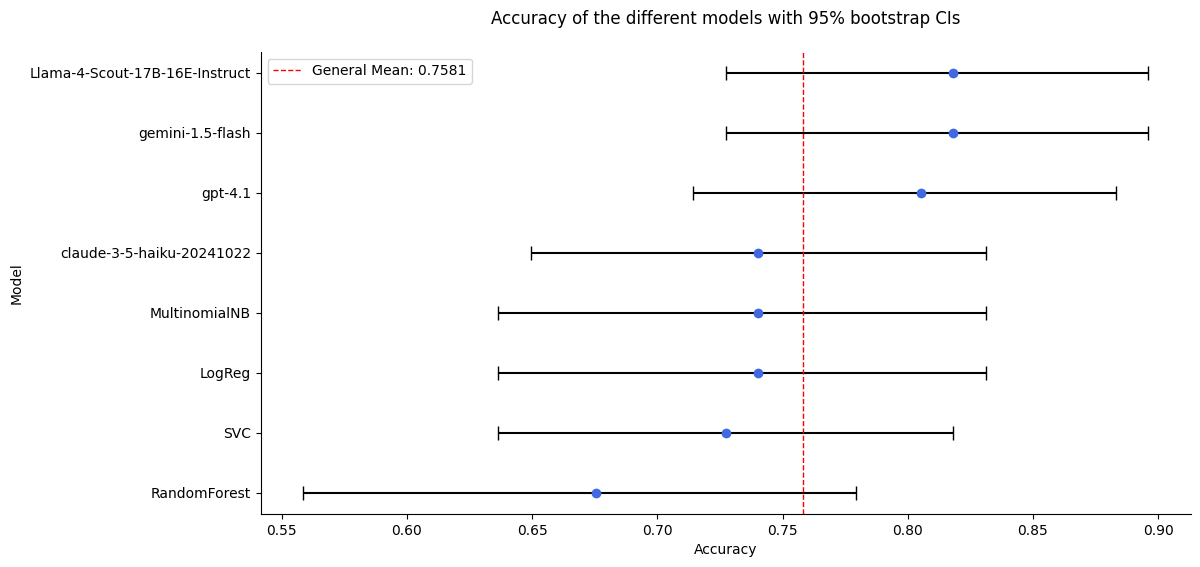

In [85]:
# Ordena o DataFrame em ordem decrescente de accuracy média
variavel_metrica = "accuracy"
lim_inf="accuracy_lo"
lim_sup="accuracy_hi"
df_estatisticas = df_ml_eval.sort_values(by=variavel_metrica, ascending=True)

# Cria o gráfico de fatores de influência com modelo na vertical e accuracy na horizontal
fig, ax = plt.subplots()
fig.set_size_inches(12, 6)

# Plota os pontos centrais (médias) e as barras de erro (limites inferior e superior)
ax.errorbar(df_estatisticas[variavel_metrica], df_estatisticas['model'], 
            xerr=[df_estatisticas[variavel_metrica] - df_estatisticas[lim_inf], 
                  df_estatisticas[lim_sup] - df_estatisticas[variavel_metrica]], 
            fmt='o', color='royalblue', ecolor='black', capsize=5)

# Calcula a média das médias
media_das_medias = df_estatisticas[variavel_metrica].mean()

# Traça a linha horizontal representando a média das médias
ax.axvline(media_das_medias, color='red', linestyle='--', linewidth=1, label=f'General Mean: {media_das_medias:.4f}')

# Ajusta o título e os rótulos
plt.title("Accuracy of the different models with 95% bootstrap CIs", pad=20)
plt.ylabel('Model')
plt.xlabel('Accuracy')
plt.legend()

# Remover bordas desnecessárias
plt.gca().spines['top'].set_visible(False)
plt.gca().spines['right'].set_visible(False)

# Exibe o gráfico
plt.show()

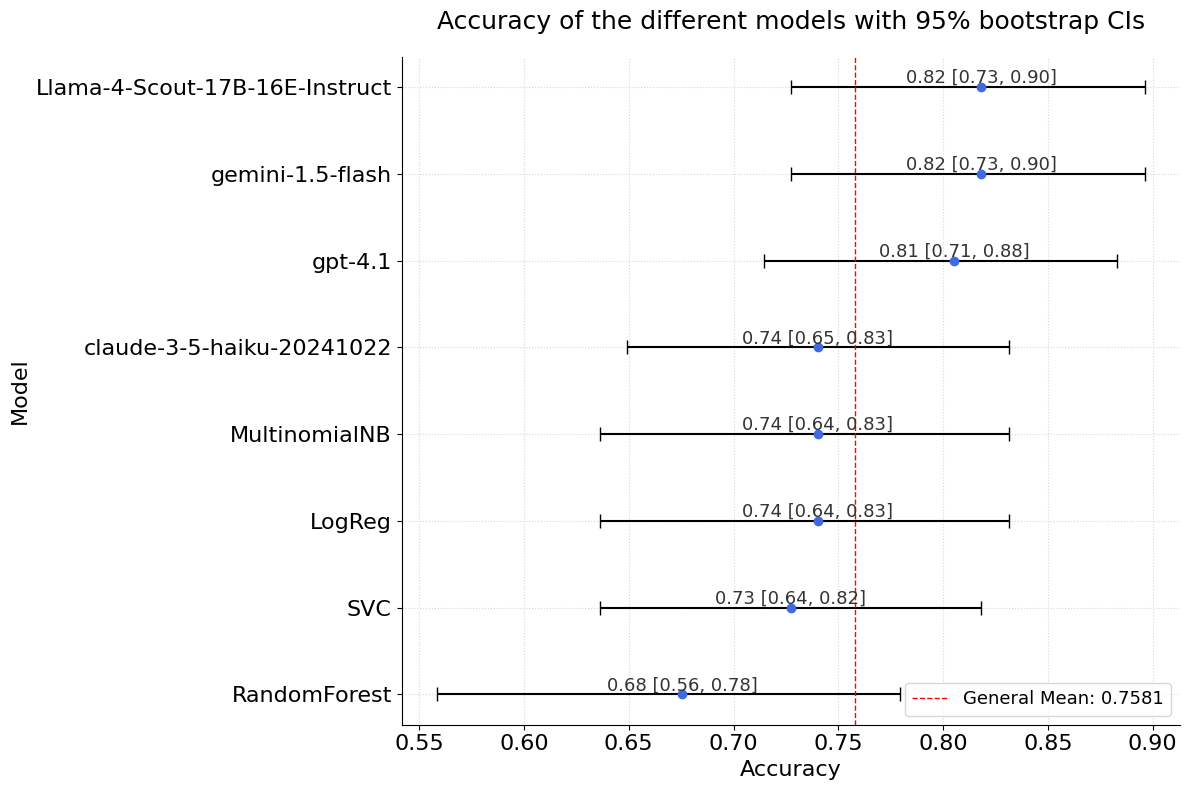

In [107]:
# Ordena o DataFrame em ordem crescente (fica do menor para o maior na horizontal)
variavel_metrica = "accuracy"
lim_inf = "accuracy_lo"
lim_sup = "accuracy_hi"
df_estatisticas = df_ml_eval.sort_values(by=variavel_metrica, ascending=True)

# Gráfico
fig, ax = plt.subplots(figsize=(12, 8))

# Pontos + barras de erro
x = df_estatisticas[variavel_metrica].values
y = df_estatisticas['model'].values
xm = (df_estatisticas[variavel_metrica] - df_estatisticas[lim_inf]).values
xp = (df_estatisticas[lim_sup] - df_estatisticas[variavel_metrica]).values

ax.errorbar(x, y, xerr=[xm, xp], fmt='o', color='royalblue',
            ecolor='black', capsize=5, elinewidth=1.5, markersize=6)

# Linha da média
media_das_medias = df_estatisticas[variavel_metrica].mean()
ax.axvline(media_das_medias, color='red', linestyle='--', linewidth=1,
           label=f'General Mean: {media_das_medias:.4f}')

# ---- Anotações nos pontos (valor central + IC) ----
# pequeno deslocamento horizontal (2% do range)
xmin = float(df_estatisticas[lim_inf].min())
xmax = float(df_estatisticas[lim_sup].max())
rng  = xmax - xmin if xmax > xmin else 1.0
dx   = 0.02 * rng
dx = 0
for xi, yi, lo, hi in zip(x, y, df_estatisticas[lim_inf], df_estatisticas[lim_sup]):
    txt = f"{xi:.2f} [{lo:.2f}, {hi:.2f}]"    
    ax.text(xi - dx, yi, txt, ha='center', va='bottom', fontsize=13, color='#333333')
   

# Título, eixos e legenda
ax.set_title("Accuracy of the different models with 95% bootstrap CIs", pad=20, fontsize=18)
ax.set_ylabel('Model',fontsize=16)
ax.set_xlabel('Accuracy', fontsize=16)
ax.legend(loc='lower right', fontsize=13)
ax.tick_params(axis='both', labelsize=16)

# Margem no eixo X para não cortar textos
ax.set_xlim(xmin - 0.05*rng, xmax + 0.05*rng)

# Limpeza visual
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.grid( linestyle=':', alpha=0.5)

plt.tight_layout()
plt.savefig('/data/codigos/dados/resultados/figuras/slr1_fase_3_acuracia.png', dpi=300, bbox_inches="tight")
plt.show()


#### F1 score

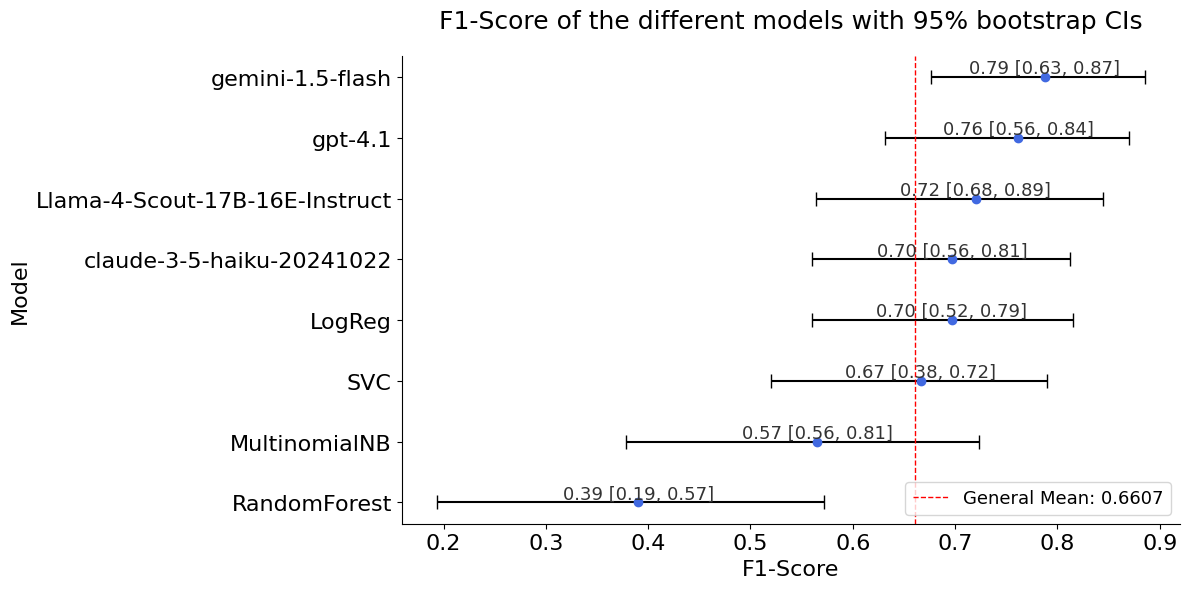

In [111]:
# Ordena o DataFrame em ordem decrescente de f1 média
variavel_metrica = "f1"
lim_inf="f1_lo"
lim_sup="f1_hi"
df_estatisticas = df_ml_eval.sort_values(by=variavel_metrica, ascending=True)

# Cria o gráfico de fatores de influência com modelo na vertical e f1 na horizontal
fig, ax = plt.subplots()
fig.set_size_inches(12, 6)

# Plota os pontos centrais (médias) e as barras de erro (limites inferior e superior)
ax.errorbar(df_estatisticas[variavel_metrica], df_estatisticas['model'], 
            xerr=[df_estatisticas[variavel_metrica] - df_estatisticas[lim_inf], 
                  df_estatisticas[lim_sup] - df_estatisticas[variavel_metrica]], 
            fmt='o', color='royalblue', ecolor='black', capsize=5)

# Calcula a média das médias
media_das_medias = df_estatisticas[variavel_metrica].mean()

# Traça a linha horizontal representando a média das médias
ax.axvline(media_das_medias, color='red', linestyle='--', linewidth=1, label=f'General Mean: {media_das_medias:.4f}')

# ---- Anotações nos pontos (valor central + IC) ----
# pequeno deslocamento horizontal (2% do range)
xmin = float(df_estatisticas[lim_inf].min())
xmax = float(df_estatisticas[lim_sup].max())
rng  = xmax - xmin if xmax > xmin else 1.0
dx   = 0.02 * rng
dx = 0
for xi, yi, lo, hi in zip(x, y, df_estatisticas[lim_inf], df_estatisticas[lim_sup]):
    txt = f"{xi:.2f} [{lo:.2f}, {hi:.2f}]"    
    ax.text(xi - dx, yi, txt, ha='center', va='bottom', fontsize=13, color='#333333')

# Ajusta o título e os rótulos
plt.title("F1-Score of the different models with 95% bootstrap CIs", pad=20,fontsize=18)
ax.set_ylabel('Model',fontsize=16)
ax.set_xlabel('F1-Score', fontsize=16)
ax.legend(loc='lower right', fontsize=13)
ax.tick_params(axis='both', labelsize=16)

# Remover bordas desnecessárias
plt.gca().spines['top'].set_visible(False)
plt.gca().spines['right'].set_visible(False)

# Exibe o gráfico
plt.tight_layout()
plt.savefig('/data/codigos/dados/resultados/figuras/slr1_fase_3_f1.png', dpi=300, bbox_inches="tight")
plt.show()

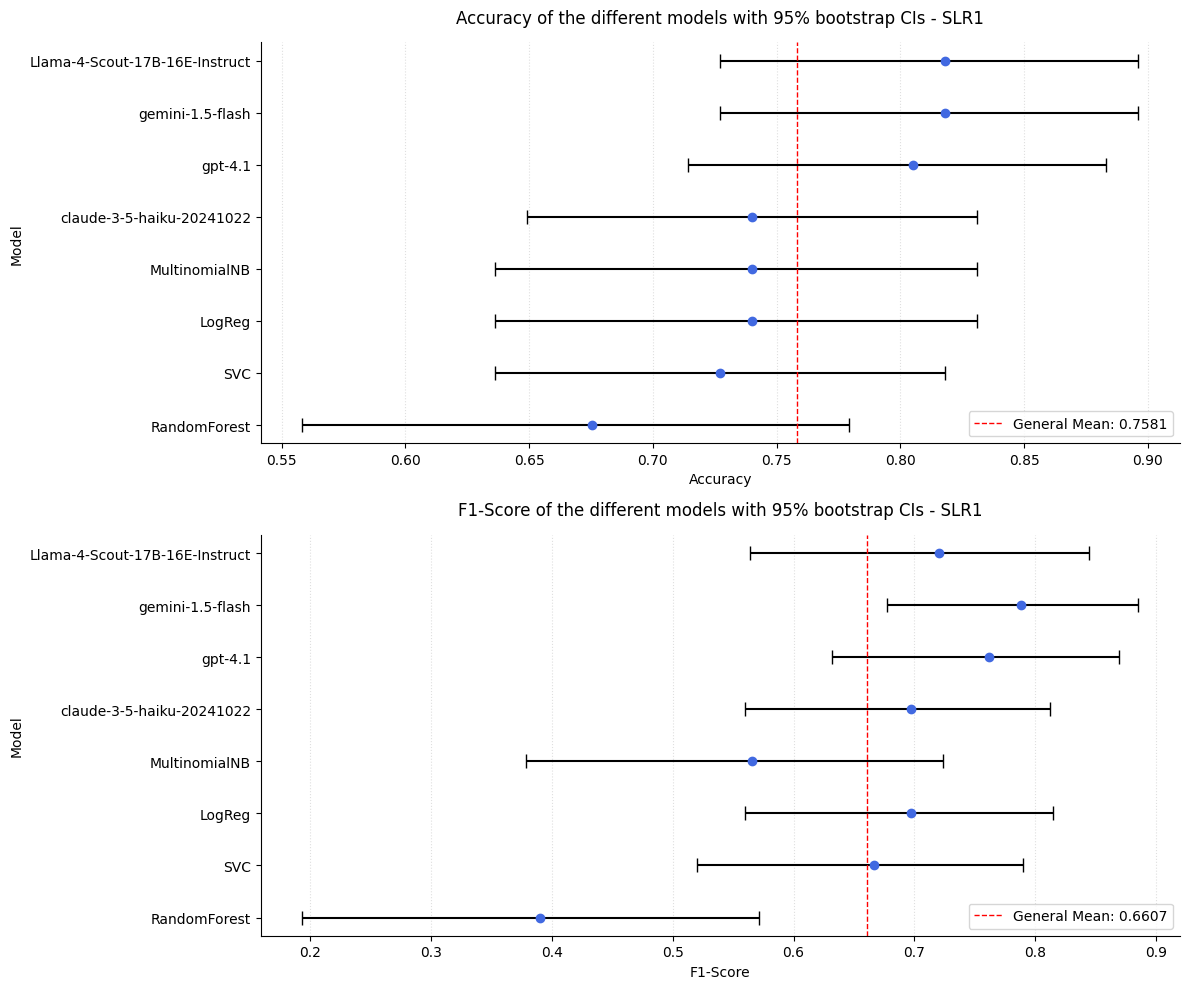

In [109]:

# --- 1) Ordenação única pelos modelos (use a de accuracy para manter alinhado)
order = (df_ml_eval.sort_values(by="accuracy", ascending=True)["model"]).tolist()

# --- 2) DataFrames ordenados conforme 'order'
acc_cols = ("accuracy", "accuracy_lo", "accuracy_hi")
f1_cols  = ("f1", "f1_lo", "f1_hi")

df_acc = df_ml_eval.set_index("model").loc[order].reset_index()
df_f1  = df_ml_eval.set_index("model").loc[order].reset_index()

# --- 3) Figura com 2 subplots empilhados
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 10), sharey=True)

# ====== PLOT 1: Accuracy ======
variavel_metrica, lim_inf, lim_sup = acc_cols
x  = df_acc[variavel_metrica]
xm = df_acc[variavel_metrica] - df_acc[lim_inf]
xp = df_acc[lim_sup] - df_acc[variavel_metrica]
y  = df_acc["model"]

ax1.errorbar(x, y, xerr=[xm, xp], fmt='o', color='royalblue', ecolor='black', capsize=5)
media_acc = x.mean()
ax1.axvline(media_acc, color='red', linestyle='--', linewidth=1, label=f'General Mean: {media_acc:.4f}')
ax1.set_title("Accuracy of the different models with 95% bootstrap CIs - SLR1", pad=14)
ax1.set_xlabel("Accuracy")
ax1.set_ylabel("Model")
ax1.legend(loc="lower right")
ax1.spines['top'].set_visible(False)
ax1.spines['right'].set_visible(False)
ax1.grid(axis="x", linestyle=":", alpha=0.4)

# ====== PLOT 2: F1 ======
variavel_metrica, lim_inf, lim_sup = f1_cols
x  = df_f1[variavel_metrica]
xm = df_f1[variavel_metrica] - df_f1[lim_inf]
xp = df_f1[lim_sup] - df_f1[variavel_metrica]
y  = df_f1["model"]

ax2.errorbar(x, y, xerr=[xm, xp], fmt='o', color='royalblue', ecolor='black', capsize=5)
media_f1 = x.mean()
ax2.axvline(media_f1, color='red', linestyle='--', linewidth=1, label=f'General Mean: {media_f1:.4f}')
ax2.set_title("F1-Score of the different models with 95% bootstrap CIs - SLR1", pad=14)
ax2.set_xlabel("F1-Score")
ax2.set_ylabel("Model")
ax2.legend(loc="lower right")
ax2.spines['top'].set_visible(False)
ax2.spines['right'].set_visible(False)
ax2.grid(axis="x", linestyle=":", alpha=0.4)

plt.tight_layout()
plt.show()


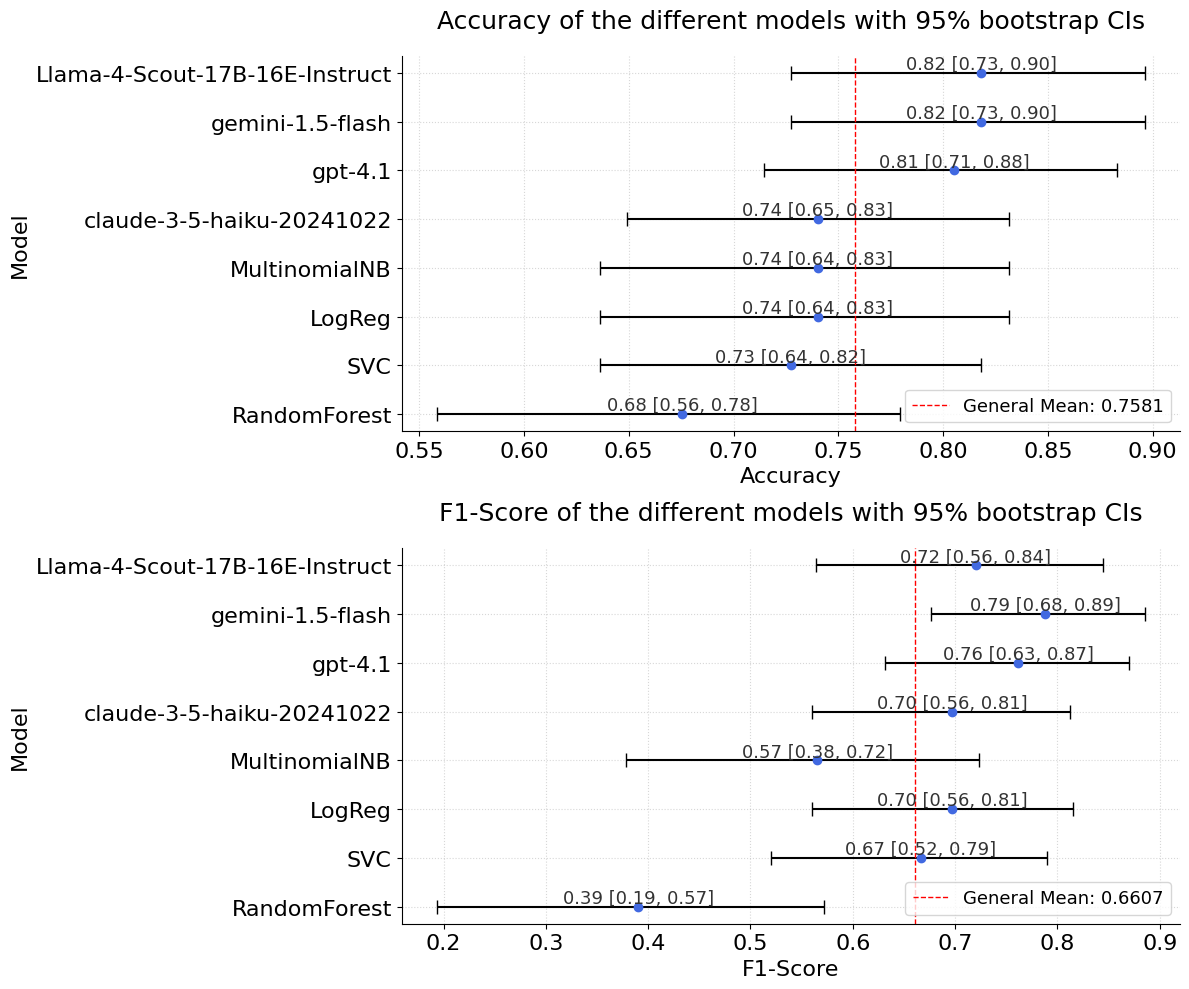

In [112]:


# ---------- Ordem única (pela accuracy) para alinhar os dois gráficos ----------
order = df_ml_eval.sort_values(by="accuracy", ascending=True)["model"].tolist()

# DataFrames reindexados na mesma ordem
df_acc = df_ml_eval.set_index("model").loc[order].reset_index()
df_f1  = df_ml_eval.set_index("model").loc[order].reset_index()

# ---------- Figura com 2 subplots empilhados, Y compartilhado ----------
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 10), sharey=True)

# ===================== PLOT 1 — ACCURACY =====================
variavel_metrica, lim_inf, lim_sup = "accuracy", "accuracy_lo", "accuracy_hi"

x  = df_acc[variavel_metrica].values
y  = df_acc["model"].values
xm = (df_acc[variavel_metrica] - df_acc[lim_inf]).values
xp = (df_acc[lim_sup] - df_acc[variavel_metrica]).values

ax1.errorbar(x, y, xerr=[xm, xp], fmt='o', color='royalblue',
             ecolor='black', capsize=5, elinewidth=1.5, markersize=6)

# linha da média
media_acc = x.mean()
ax1.axvline(media_acc, color='red', linestyle='--', linewidth=1,
            label=f'General Mean: {media_acc:.4f}')

# anotações
xmin = float(df_acc[lim_inf].min())
xmax = float(df_acc[lim_sup].max())
rng  = xmax - xmin if xmax > xmin else 1.0
dx   = 0.00 * rng  
for xi, yi, lo, hi in zip(x, y, df_acc[lim_inf], df_acc[lim_sup]):
    txt = f"{xi:.2f} [{lo:.2f}, {hi:.2f}]"
    ax1.text(xi - dx, yi, txt, ha='center', va='bottom', fontsize=13, color='#333')

# estética
ax1.set_title("Accuracy of the different models with 95% bootstrap CIs", pad=20, fontsize=18)
ax1.set_ylabel('Model', fontsize=16)
ax1.set_xlabel('Accuracy', fontsize=16)
ax1.legend(loc='lower right', fontsize=13)
ax1.tick_params(axis='both', labelsize=16)
ax1.set_xlim(xmin - 0.05*rng, xmax + 0.05*rng)
ax1.spines['top'].set_visible(False)
ax1.spines['right'].set_visible(False)
ax1.grid(linestyle=':', alpha=0.5)

# ===================== PLOT 2 — F1 =====================
variavel_metrica, lim_inf, lim_sup = "f1", "f1_lo", "f1_hi"

x  = df_f1[variavel_metrica].values
y  = df_f1["model"].values
xm = (df_f1[variavel_metrica] - df_f1[lim_inf]).values
xp = (df_f1[lim_sup] - df_f1[variavel_metrica]).values

ax2.errorbar(x, y, xerr=[xm, xp], fmt='o', color='royalblue',
             ecolor='black', capsize=5, elinewidth=1.5, markersize=6)

# linha da média
media_f1 = x.mean()
ax2.axvline(media_f1, color='red', linestyle='--', linewidth=1,
            label=f'General Mean: {media_f1:.4f}')

# anotações
xmin2 = float(df_f1[lim_inf].min())
xmax2 = float(df_f1[lim_sup].max())
rng2  = xmax2 - xmin2 if xmax2 > xmin2 else 1.0
dx2   = 0.00 * rng2

for xi, yi, lo, hi in zip(x, y, df_f1[lim_inf], df_f1[lim_sup]):
    txt = f"{xi:.2f} [{lo:.2f}, {hi:.2f}]"
    ax2.text(xi - dx2, yi, txt, ha='center', va='bottom', fontsize=13, color='#333')

# estética
ax2.set_title("F1-Score of the different models with 95% bootstrap CIs", pad=20, fontsize=18)
ax2.set_ylabel('Model', fontsize=16)
ax2.set_xlabel('F1-Score', fontsize=16)
ax2.legend(loc='lower right', fontsize=13)
ax2.tick_params(axis='both', labelsize=16)
ax2.set_xlim(xmin2 - 0.05*rng2, xmax2 + 0.05*rng2)
ax2.spines['top'].set_visible(False)
ax2.spines['right'].set_visible(False)
ax2.grid(linestyle=':', alpha=0.5)

plt.tight_layout()
# opcional: salvar figura única
plt.savefig('/data/codigos/dados/resultados/figuras/slr1_fase_3_acc_f1.png', dpi=300, bbox_inches="tight")
plt.show()
